# Building Footprint Area Comparison

Compare building area estimates across three sources over the NearMap USC sample tiles:

| Source | Column | Description |
|--------|--------|-------------|
| Assessor APD | `SQFTmain` | Recorded floor area |
| NearMap | `areaSqft`, `NM_BLDG_AREA` | Detected footprint area |
| LARIAC 2020 | `AREA`, geometry | Mapped building footprint |

In [1]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt

# Change to project root before importing local src modules
os.chdir('../..')
from src.geoadmin import load_laraic, get_landbase_bymask, load_assessor_parcels_bygeom


## 1. Load Data

In [ ]:
# NearMap sample tiles
NEARMAP_DIR  = '/Users/adamswietek/Downloads/USC_Nearmap_Sample_Data'
NEARMAP_TILE = f'{NEARMAP_DIR}/IMAGERY_SAMPLE_EPSG3857_Date20251005/Tiles.shp'
nearmap_tile = gpd.read_file(NEARMAP_TILE)

# NearMap × Assessor joined parcels
BASE_DIR    = '/Users/adamswietek/Documents/PostDoc/HiddenHousing/'
ASSESSOR_NM = f'{BASE_DIR}/data/processed/nm_parcel_joined.gpkg'
assessor_nm = gpd.read_file(ASSESSOR_NM)
CRS = assessor_nm.crs
nearmap_tile.to_crs(CRS, inplace=True)
print(CRS)

# LA County Assessor parcels (clipped to NearMap extent)
fp = '/Users/adamswietek/Documents/PostDoc/data/raw_la/LACounty_Parcels.gdb'
CRS = gpd.read_file(fp, rows=1).crs
assessor_parcel = gpd.read_file(fp, mask=nearmap_tile.to_crs(CRS))
assessor_parcel.to_crs(CRS, inplace=True)


EPSG:2229


ERROR 1: PROJ: internal_proj_identify: /Users/adamswietek/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
ERROR 1: PROJ: internal_proj_identify: /Users/adamswietek/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/pyogrio/core.py:280: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiPolygon' is converted to 'MultiPolygon Z'
  return ogr_read_info(
/opt/homebrew/Caskroom/miniforge/base/envs/samgeo/lib/python3.12/site-packages/geopandas/io/file.py:521: UserWarning: More than one layer found in 'LARIAC6_Buildings_2020.gdb': 'LARIAC6_BUILDINGS_2020' (default), 'LARIAC5_BUILDINGS_DELETED_2020'. Specify layer parameter to avoid this warning.
  crs = pyogrio.read_info(pa

## 2. Prep

Spatial join LARIAC building centroids → assessor parcel polygons to assign each building an AIN.
Also aggregate `SQFTmain` sub-columns into a single field.

In [58]:
lariac['poly'] = lariac.geometry
lariac_centroid = lariac.set_geometry(lariac.centroid)
assessor_lar = gpd.sjoin(lariac_centroid, assessor_parcel, how = 'inner')
assessor_lar['geom_area'] = assessor_lar.set_geometry('poly')['geometry'].area

In [ ]:
sqftcols = assessor_parcel.columns[assessor_parcel.columns.str.contains('SQFTmain')]
assessor_parcel['assr_sqftmain'] = assessor_parcel[sqftcols].sum(1)

## 3. Comparison Table

Aggregate each source by AIN for side-by-side comparison.

In [75]:
results = {
    'usetype': assessor_parcel.groupby('AIN')['UseDescription'].first(),
    'assr_sqftmain':assessor_parcel.groupby('AIN')['assr_sqftmain'].sum(),
    'assr_sqftmain_check':assessor_parcel.groupby('AIN')['assr_sqftmain'].first(),
    'nm_area': assessor_nm.groupby('AIN')['areaSqft'].sum(),
    'nm_geomarea':assessor_nm.groupby('AIN')['NM_BLDG_AREA'].sum(),
    'lar_area':assessor_lar.groupby('AIN')['AREA'].sum(),
    'lar_geomarea':assessor_lar.groupby('AIN')['geom_area'].sum()
}

df = pd.DataFrame(results)


## 4. Scatter Plots

Each plot compares two area measures on a log-log scale. Dashed line = 1:1 reference.

**Sanity check:** assessor `SQFTmain` summed vs. first-record — should be 1:1 for single-record AIns.

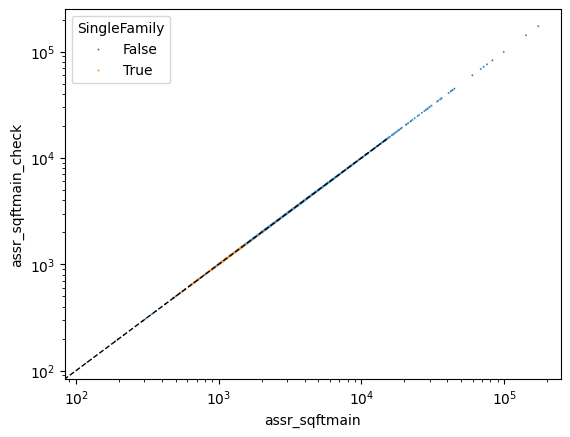

In [76]:
sns.scatterplot(data = df, x= 'assr_sqftmain', y = 'assr_sqftmain_check', s= 2, hue = df['usetype'] == 'Single')
plt.legend(title = 'SingleFamily')
plt.xscale('log'), plt.yscale('log')
plt.plot([0, 15000], [0, 15000], 'k--', lw=1, label='1:1')

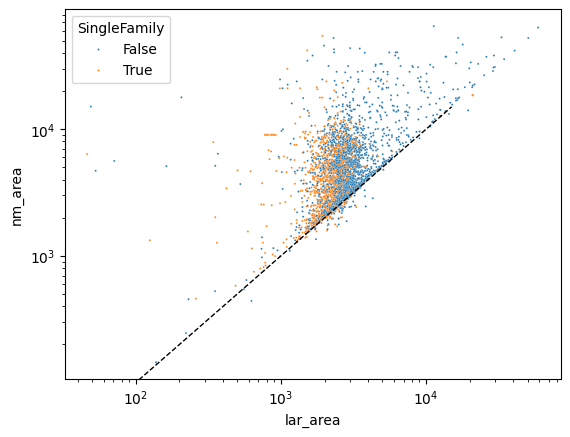

In [69]:
sns.scatterplot(data = df, x= 'lar_area', y = 'nm_area', s= 2, hue = df['usetype'] == 'Single')
plt.legend(title = 'SingleFamily')
plt.xscale('log'), plt.yscale('log')
plt.plot([0, 15000], [0, 15000], 'k--', lw=1, label='1:1')

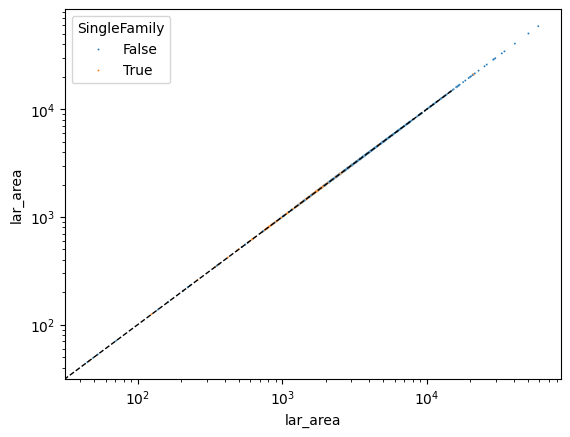

In [67]:
sns.scatterplot(data = df, x= 'lar_area', y = 'lar_area', s= 2, hue = df['usetype'] == 'Single')
plt.legend(title = 'SingleFamily')
plt.xscale('log'), plt.yscale('log')
plt.plot([0, 15000], [0, 15000], 'k--', lw=1, label='1:1')

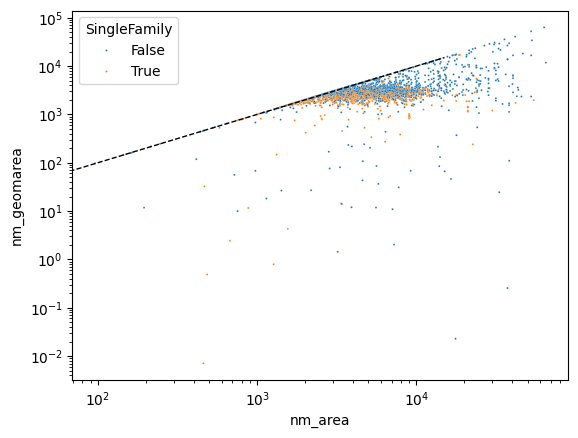

In [66]:
sns.scatterplot(data = df, x= 'nm_area', y = 'nm_geomarea', s= 2, hue = df['usetype'] == 'Single')
plt.legend(title = 'SingleFamily')
plt.xscale('log'), plt.yscale('log')
plt.plot([0, 15000], [0, 15000], 'k--', lw=1, label='1:1')

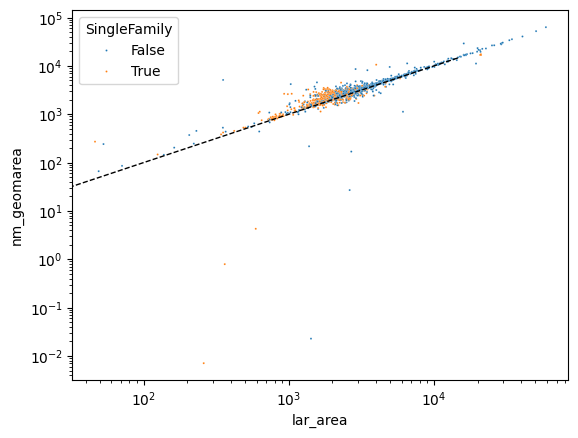

In [68]:
sns.scatterplot(data = df, x= 'lar_area', y = 'nm_geomarea', s= 2, hue = df['usetype'] == 'Single')
plt.legend(title = 'SingleFamily')
plt.xscale('log'), plt.yscale('log')
plt.plot([0, 15000], [0, 15000], 'k--', lw=1, label='1:1')

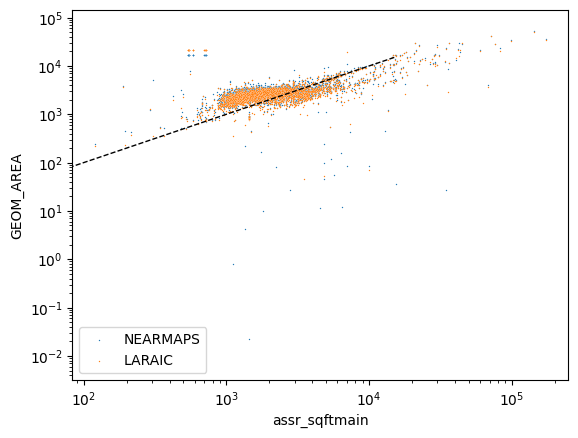

In [78]:
sns.scatterplot(data = df, x= 'assr_sqftmain', y = 'nm_geomarea', label = 'NEARMAPS', s = 1)
sns.scatterplot(data = df, x= 'assr_sqftmain', y = 'lar_area', label = 'LARAIC', s= 1)

plt.xscale('log'), plt.yscale('log'), plt.ylabel('GEOM_AREA')
plt.plot([0, 15000], [0, 15000], 'k--', lw=1, label='1:1')

Text(0.5, 0, 'area metric')

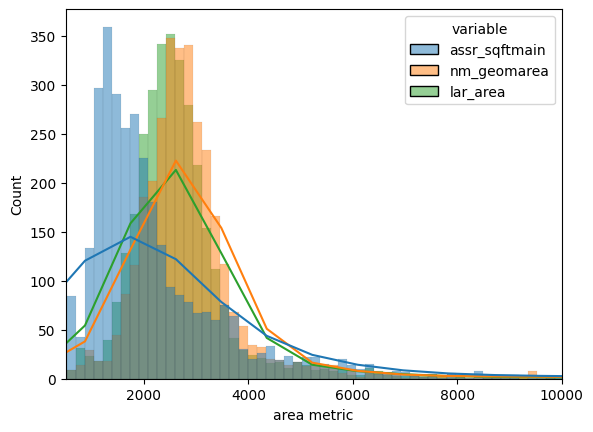

In [99]:
Z = df[['assr_sqftmain','nm_geomarea','lar_area']].melt()

sns.histplot(data = Z, x = 'value', hue = 'variable', kde = True, bins = 1000, palette= 'tab10')

plt.xlim((500,10_000))
plt.xlabel('area metric')

Text(0.5, 1.0, 'Singel Family Only')

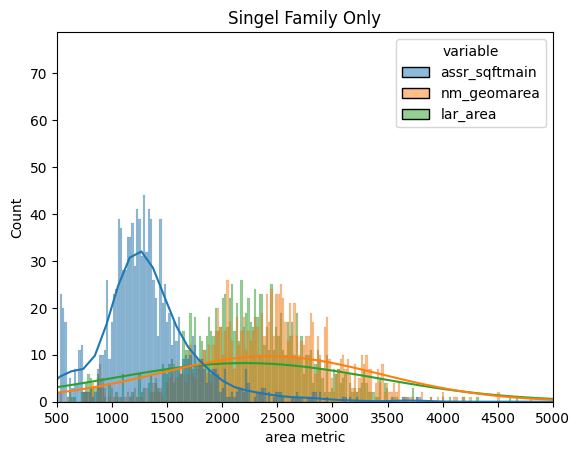

In [102]:
Z = df.query('usetype == "Single"')[['assr_sqftmain','nm_geomarea','lar_area']].melt()

sns.histplot(data = Z, x = 'value', hue = 'variable', kde = True, bins = 1000, palette= 'tab10')

plt.xlim((500,5_000))
plt.xlabel('area metric')
plt.title('Singel Family Only')

## 5. Reusable Loader

Helper to load landbase, assessor, and LARIAC for any neighborhood AOI and year combination.

In [ ]:
LANDBASE_YR = 2023
ASSESSOR_YR = 2020
LARIAC_YR   = 2020

def load_data_by_year(neighborhood, lb_yr, apd_yr, lar_yr, source='lariac'):
    landbase_parcels = get_landbase_bymask(neighborhood, lb_yr)

    polygon_geometry = neighborhood.to_crs(4326).iloc[0].geometry
    assessor_data = load_assessor_parcels_bygeom(polygon_geometry)
    assessor_data = assessor_data.loc[assessor_data.RollYear == apd_yr]
    assessor_data = assessor_data.to_crs(landbase_parcels.crs)

    if source == 'lariac':
        lariac_structures = load_laraic(neighborhood, lar_yr)
        lariac_structures = lariac_structures.to_crs(landbase_parcels.crs)

    return landbase_parcels, assessor_data, lariac_structures

aoi = nearmap_tile.dissolve()
landbase, assessor, lariac = load_data_by_year(
    aoi, lb_yr=LANDBASE_YR, apd_yr=ASSESSOR_YR, lar_yr=LARIAC_YR)

